# Simulation of a Si homo pn-junction

The following code loads the needed modules.

In [1]:
import scipy.sparse as sparse 
from scipy.sparse.linalg import spsolve

import numpy as np

import matplotlib.pyplot as plt

from synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, hole_current_density, electron_current_density

import synumses.one_dimension.parameters as parameters

from synumses.one_dimension.functions import calc_p_density, calc_n_density


import synumses.one_dimension.solver as solver

print(parameters.bernoulli_limit)

0.0001


By default the library uses the following parameters for silicon:<br>
* **parameters.n  = 400**, 400 cell points
* **parameters.lx = 400E-9**, total length of device $l_\mathrm{x} = 400\,\mathrm{nm}$
* **parameters.C[000:199]   = -1E24**, left part of device is p-doped $N_\mathrm{A} = 10^{24}\,\mathrm{m}^{-3}$
* **parameters.C[200:399] = +1E24**, right part of device is p-doped $N_\mathrm{D} = 10^{24}\,\mathrm{m}^{-3}$
* **parameters.Epsilon[0:399] = $\varepsilon_0 \cdot \varepsilon_\mathrm{r, Si}$**, materialparameter von silicon 
* **parameters.Ec[0:399] = $1.12\,\mathrm{eV}$**, energie level of conduction band
* **parameters.Ev[0:399] = $0\,\mathrm{eV}$**, energie level of valence band
* **parameters.Cau[0:399] = $2.3\cdot 10^{-20} \mathrm{\dfrac{m^3}{s}}$** defines the recombination rate :
    $\dfrac{\mathrm{d}n}{\mathrm{d}t} = Cau \left(n \cdot p - n_\mathrm{i}^2 \right)$


Now, we plot the default band diagramm.

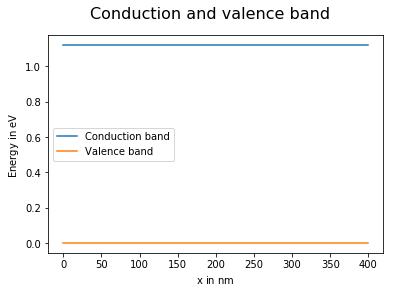

In [2]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence band", fontsize=16)

axis.plot(parameters.Ec, label='Conduction band')
axis.plot(parameters.Ev, label='Valence band')


plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"Energy in $\mathrm{eV}$")

#plt.ylim (-.2,1.4)

axis.legend(loc = 6)

The following function calculates the potential according the doping level.

In [3]:
parameters.init_potential()

Now, we plot the potential according the doping level.

<function matplotlib.pyplot.show(*args, **kw)>

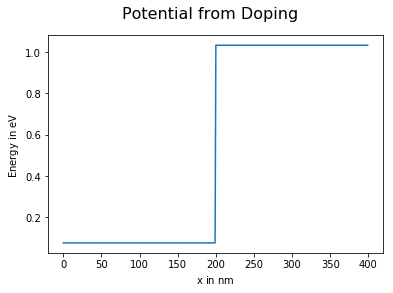

In [4]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from Doping", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"Energy in $\mathrm{eV}$")

axis.plot(parameters.u[0::3])
plt.show

Now, let's plot the band diagramm considering diffusion but no biasing.<br>
One Simulation **solver.solve_no_bias()** must be performed befor simulatoins with biasing.

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


Norm of b:  1.3554825420855316
Norm of x: 0.9565795162325583
Norm of b:  1.1785589553589804
Norm of x: 0.6041109049583759
Norm of b:  3.853010903422556
Norm of x: 0.17157219085730804
Norm of b:  0.6422845374343864
Norm of x: 0.02298468199750444
Norm of b:  0.9428680066249464
Norm of x: 0.000618716731224648
Norm of b:  1.5272410666299931
Norm of x: 5.957874358055762e-07
Norm of b:  1.1486713879010926
Norm of x: 1.4574506253180134e-12
Norm of b:  1.3506293740959119
Norm of x: 4.971425454439189e-13
Norm of b:  2.078751718843743
Norm of x: 6.6942011566526e-13


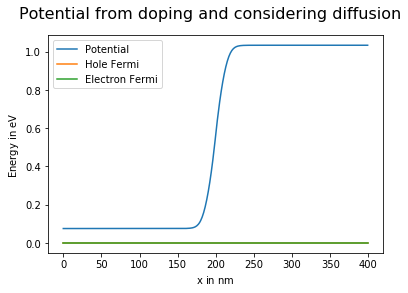

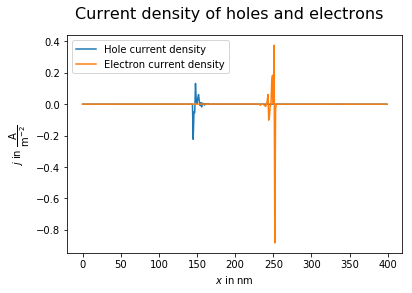

In [5]:
solver.solve_bias(0,0)

#Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from doping and considering diffusion", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"Energy in $\mathrm{eV}$")

axis.plot(parameters.u[0::3], label='Potential')
axis.plot(parameters.u[1::3], label='Hole Fermi')
axis.plot(parameters.u[2::3], label='Electron Fermi')
plt.legend()
plt.show()

old_pot = parameters.u[0::3]

# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

plt.xlabel(r"$x$ in $\mathrm{nm}$")
plt.ylabel(r"$j$ in $\mathrm{\dfrac{A}{m^{-2}}}$")

axis.plot(j_p, label='Hole current density')
axis.plot(j_n, label='Electron current density')
axis.legend()
plt.show()



Now, let's apply a voltage of $0\,\mathrm{mV}$ ! <br>

Plot the:
* potential,
* electron and hole density,
* electron and hole current density, and

Norm of b before loop:
2.078751718843743
Norm of b:  1.6404119366201872
Norm of x: 2.9759698608233935e-13
Norm of b:  1.5283424782049584
Norm of x: 2.2337780921052308e-13
Norm of b:  0.7642049811152869
Norm of x: 4.988403380886294e-13


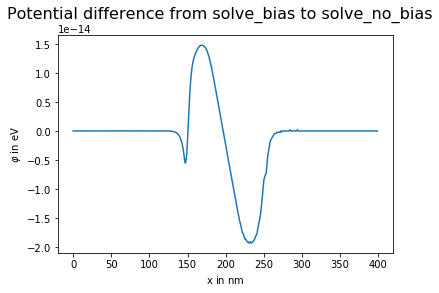

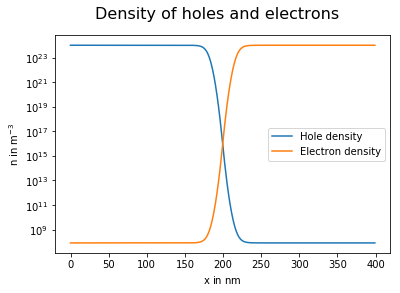

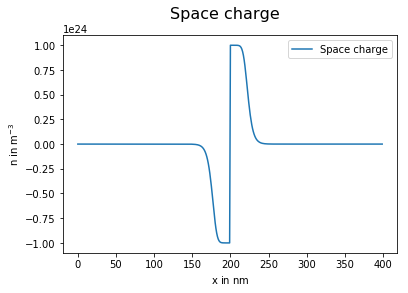

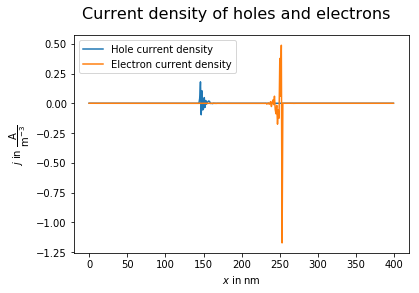

In [6]:
bias_point = -0.0
print("Norm of b before loop:")
print(np.linalg.norm(parameters.b))

solver.solve_bias(bias_point,0)

# Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential difference from solve_bias to solve_no_bias", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"$\varphi$ in $\mathrm{eV}$")

axis.plot(parameters.u[0::3]-old_pot, label='Potential')
#axis.plot(old_pot, label='Potential')
plt.show()


# Quasi fermi levels of electrons and holes
#fig, axis = plt.subplots(1,1, sharey=True)
#fig.suptitle("Quasi fermi levels of holes and electrons", fontsize=16)

#axis.plot(parameters.u[1::3], label='Quasi fermi levels of hole')
#axis.plot(parameters.u[2::3], label='Quasi fermi levels of electrons')
#axis.legend()
#plt.show()



# Electron and hole density
calc_p_density()
calc_n_density()
p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"n in $\mathrm{m^{-3}}$")

axis.semilogy(p, label='Hole density')
axis.semilogy(n, label='Electron density')
axis.legend()
plt.show()

# Space charge

calc_p_density()
calc_n_density()
p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Space charge", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"n in $\mathrm{m^{-3}}$")

axis.plot(p-n+parameters.C, label='Space charge')

axis.legend()
plt.show()

# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

plt.xlabel(r"$x$ in $\mathrm{nm}$")
plt.ylabel(r"$j$ in $\mathrm{\dfrac{A}{m^{-3}}}$")

axis.plot(j_p, label='Hole current density')
axis.plot(j_n, label='Electron current density')
axis.legend()
plt.show()

The total current density is composed by the hole and electron current density. <br>

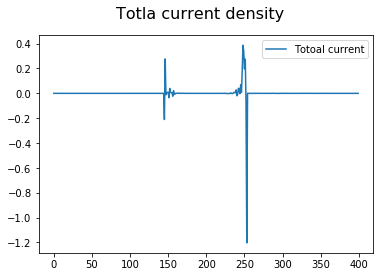

0.0008632524876320701

In [7]:
j_total = hole_current_density() + electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Totla current density", fontsize=16)

axis.plot(j_total, label='Totoal current')

axis.legend()
plt.show()

np.mean(j_total)

Now let's simulate a voltage sweep to get the diode characteristic. <br>
For the simulation to converge, the voltage must be ramped up slowly.<br>
The bias points are printed and stored in the arrays **voltage** and **current_density**.

In [8]:
u_start = 0.0
u_stop  = .7
u_step  = 0.025

voltage = []
current_density = []

bias_points = np.linspace(u_start, u_stop, int((u_stop-u_start)/(u_step) + 1))
print(bias_points)
for bias_point in bias_points:

    solver.solve_bias(bias_point,0)   
    
    j = np.mean(hole_current_density() + electron_current_density())
    voltage.append(bias_point)
    current_density.append(j)
    print(bias_point, ",", j)
  

[0.         0.02592593 0.05185185 0.07777778 0.1037037  0.12962963
 0.15555556 0.18148148 0.20740741 0.23333333 0.25925926 0.28518519
 0.31111111 0.33703704 0.36296296 0.38888889 0.41481481 0.44074074
 0.46666667 0.49259259 0.51851852 0.54444444 0.57037037 0.5962963
 0.62222222 0.64814815 0.67407407 0.7       ]
Norm of b:  1.8256229505795223
Norm of x: 3.3235104425627683e-13
Norm of b:  0.8251474219785422
Norm of x: 4.661408458188473e-13
0.0 , 0.0018518959496990276
Norm of b:  186666666666.6664
Norm of x: 0.598317967604409
Norm of b:  1.6468183384147455
Norm of x: 0.0461447041031265
Norm of b:  0.9689609838750453
Norm of x: 0.0024445525525568484
Norm of b:  0.930339745154253
Norm of x: 8.366370342279629e-06
Norm of b:  1.369144065002156
Norm of x: 1.1223118170040747e-10
Norm of b:  1.2269821541865185
Norm of x: 4.2777673745485626e-13
Norm of b:  0.844516007086354
Norm of x: 9.334155518499932e-13
0.025925925925925925 , 0.0024278878216054613
Norm of b:  186666666666.6664
Norm of x: 0.601

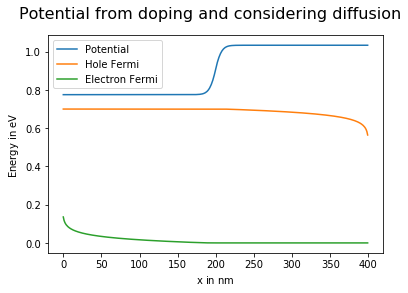

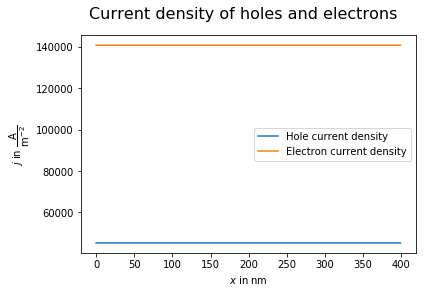

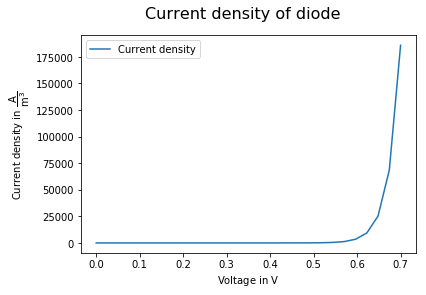

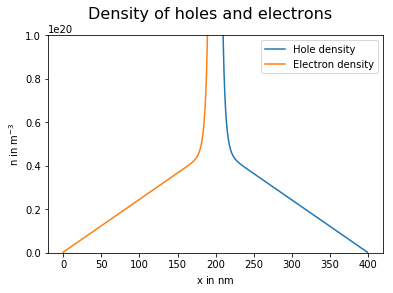

In [9]:
#Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from doping and considering diffusion", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"Energy in $\mathrm{eV}$")

axis.plot(parameters.u[0::3], label='Potential')
axis.plot(parameters.u[1::3], label='Hole Fermi')
axis.plot(parameters.u[2::3], label='Electron Fermi')
plt.legend()
plt.show()

old_pot = parameters.u[0::3]

# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

plt.xlabel(r"$x$ in $\mathrm{nm}$")
plt.ylabel(r"$j$ in $\mathrm{\dfrac{A}{m^{-2}}}$")

axis.plot(j_p, label='Hole current density')
axis.plot(j_n, label='Electron current density')
axis.legend()
plt.show()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of diode", fontsize=16)

axis.plot(voltage, current_density, label='Current density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Current density in $\mathrm{\dfrac{A}{m^3}}$")

axis.legend()
#plt.ylim(-1E-6,1E-6)
plt.show()

# Electron and hole density
calc_p_density()
calc_n_density()
p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"n in $\mathrm{m^{-3}}$")

#axis.semilogy(p, label='Hole density')
axis.plot(p, label='Hole density')
#axis.semilogy(n, label='Electron density')
axis.plot(n, label='Electron density')

axis.legend()
plt.ylim(0, 1E20)
plt.show()

In [14]:
solver.solve_bias(0,0)

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


True